Project 1: Data Collection and Initial Analysis of Stock Market Data
Name Ayleen Santander

In [51]:
#Import Libraries
import gc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [52]:
print(os.getcwd())

C:\Users\aylee\M.11_Intro_AI


In [53]:
#Verify after copy
print([f for f in os.listdir() if f.endswith('.csv')])

['historical_stocks.csv', 'historical_stock_prices.csv', 'results_cv_summary.csv', 'results_test_table.csv', 'results_validation_table.csv', 'stock_prepared.csv']


In [54]:
#Load + first rows
stock_prices = pd.read_csv('historical_stock_prices.csv', dtype={'volume': 'float64'}, low_memory=False)
hist_stock = pd.read_csv('historical_stocks.csv', low_memory=False)
print(stock_prices.head(), '\n')
print(hist_stock.head())

  ticker   open  close  adj_close    low   high     volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013-05-14 

  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURE

In [57]:
#Structure, missing values, duplicates for BOTH datasets 
for name, df in [('stock_prices', stock_prices), ('hist_stock', hist_stock)]:
    print(f'===== {name} =====')
    print('Shape:', df.shape)
    df.info()
    print('Missing values:\n', df.isnull().sum())
    print('Full duplicate rows:', df.duplicated().sum(), '\n')
print('Duplicate ticker + date:', stock_prices.duplicated(subset=['ticker', 'date']).sum())

===== stock_prices =====
Shape: (20973889, 8)
<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     str    
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     float64
 7   date       str    
dtypes: float64(6), str(2)
memory usage: 1.3 GB
Missing values:
 ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64
Full duplicate rows: 0 

===== hist_stock =====
Shape: (6460, 5)
<class 'pandas.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ticker    6460 non-null   str  
 1   exchange  6460 non-null   str  
 2   name      6460 non-null   str  
 3   sector    5020 non-null   str  
 4   industry  5020 non-null   

In [58]:
#Fix te date column and adj_close
stock_prices['date'] = pd.to_datetime(stock_prices['date'], errors='coerce')
print('dtype:', stock_prices['date'].dtype)
print('Earliest date:', stock_prices['date'].min())
print('Latest date:  ', stock_prices['date'].max())
stock_prices = stock_prices.set_index('date').sort_index()

print('--'*45)

stock_prices['adj_close'] = pd.to_numeric(stock_prices['adj_close'], errors='coerce')
print(stock_prices['adj_close'].isna().sum())

dtype: datetime64[us]
Earliest date: 1970-01-02 00:00:00
Latest date:   2018-08-24 00:00:00
------------------------------------------------------------------------------------------
0


In [76]:
print(stock_prices.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 20973889 entries, 1970-01-02 to 2018-08-24
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     str    
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     float64
dtypes: float64(6), str(1)
memory usage: 1.3 GB
None


In [ ]:
#Group by monthly each ticket
monthly = stock_prices.groupby('ticker')['close'].resample('ME').mean()
print(monthly)

Part 3: Data Segmentation by Decade

In [12]:
#1. Create a new column in the DataFrame for prices to represent the decade.
stock_prices['decade'] = (stock_prices.index.year // 10) * 10
decades = {d: g for d, g in stock_prices.groupby('decade')}
for d, df in decades.items():
    print(f"{d}s — {len(df):,} rows, {df['ticker'].nunique()} tickers")

decade
1970     164499
1980    1470571
1990    3427832
2000    6572053
2010    9338934
Name: count, dtype: int64
------------------------------------------------------------------------------------------
           ticker        open       close   adj_close         low        high  \
date                                                                            
1970-01-02    CNP   11.099500   11.169750    0.107916   10.994125   11.204875   
1970-01-02    CAT    3.541667    3.458333    0.378521    3.447917    3.541667   
1970-01-02     KO    0.856771    0.856771    0.017364    0.850260    0.856771   
1970-01-02    NAV  251.250000  261.250000  169.416168  251.250000  261.250000   
1970-01-02    MMM    6.851562    6.851562    0.438697    6.843750    6.890625   

               volume  decade  
date                           
1970-01-02    24400.0    1970  
1970-01-02   276000.0    1970  
1970-01-02  1104000.0    1970  
1970-01-02      900.0    1970  
1970-01-02    72000.0    1970  


In [14]:
#2. Segment the data into separate DataFrames for each decade for easier comparative analysis.
#Dictionary keyed by decade
decades= {d: g for d, g in stock_prices.groupby('decade')}

for d, df in decades.items():
    print(f'Decade: {d}')
    print(df.head())
    print('--'*45)

Decade: 1970s
           ticker        open       close   adj_close         low        high  \
date                                                                            
1970-01-02    CNP   11.099500   11.169750    0.107916   10.994125   11.204875   
1970-01-02    CAT    3.541667    3.458333    0.378521    3.447917    3.541667   
1970-01-02     KO    0.856771    0.856771    0.017364    0.850260    0.856771   
1970-01-02    NAV  251.250000  261.250000  169.416168  251.250000  261.250000   
1970-01-02    MMM    6.851562    6.851562    0.438697    6.843750    6.890625   

               volume decade  
date                          
1970-01-02    24400.0  1970s  
1970-01-02   276000.0  1970s  
1970-01-02  1104000.0  1970s  
1970-01-02      900.0  1970s  
1970-01-02    72000.0  1970s  
------------------------------------------------------------------------------------------
Decade: 1980s
           ticker       open      close  adj_close        low       high  \
date                

Part 4: Exploratory Data Analysis by Decade

In [18]:
#1. Merge the stock_prices dataset with the stock dataset using the appropriate key to include sector
#information with the stock prices.
#inspect the other dataset
print(f'Columns List:', hist_stock.columns.tolist())
print(f'Shape Rows and Columns:', hist_stock.shape)
print(f'Duplicated values:', hist_stock['ticker'].duplicated().sum())

Columns List: ['ticker', 'exchange', 'name', 'sector', 'industry']
Shape Rows and Columns: (6460, 5)
Duplicated values: 0


In [19]:
#Merge both dataset with pd.merge
merged = (
    stock_prices.reset_index()
    .merge(hist_stock[['ticker', 'sector']], on='ticker', how='left')
    .set_index('date')
)

#check coverage
print(merged['sector'].isna().sum())            # tickers with no sector match
print(merged[merged['sector'].isna()]['ticker'].unique()[:20])
print(merged.shape[0], stock_prices.shape[0])   # must match — no row inflation

2549449
<StringArray>
['USAU',  'ASA',  'JHI',  'ADX',  'MCI',  'BIF', 'INSI',  'JHS',   'TY',
  'GAM',  'WRE',  'MXF',  'VBF',   'KF',  'ASG',  'EEA',  'GAB',   'ZF',
  'USA',  'MFM']
Length: 20, dtype: str
20973889 20973889


In [20]:
#Convert to save space:
merged['sector'] = merged['sector'].astype('category')

In [21]:
#2. For each decade DataFrame, calculate summary statistics (mean, median, standard deviation)
#for the Open, High, Low, Close, and Volume columns. Use .agg()
cols =['open', 'high', 'low', 'close', 'volume']
for d, df in decades.items():
  print(f'\n==={d}s===')
  print(df[cols].agg(['mean', 'median', 'std']).round(2))


===1970s===
         open   high    low  close      volume
mean    12.49  12.64  12.37  12.49   724893.64
median   2.79   2.84   2.77   2.79   187200.00
std     46.98  47.48  46.51  46.99  1377365.79

===1980s===
          open    high     low   close      volume
mean     16.81   17.10   16.56   16.82   837523.35
median    5.00    5.08    4.96    5.00    64600.00
std     573.05  582.81  562.26  575.03  4510088.44

===1990s===
           open     high      low    close      volume
mean      45.29    46.87    43.81    45.30   863527.19
median    10.58    10.75    10.44    10.59    62200.00
std     1391.11  1464.63  1329.33  1391.58  5834011.90

===2000s===
           open     high      low    close      volume
mean     122.30   125.65   119.17   122.44  1383562.38
median    16.58    16.87    16.30    16.58   133400.00
std     4485.64  4703.97  4318.82  4509.78  9230142.84

===2010s===
           open     high      low    close       volume
mean      65.26    66.72    63.92    65.28   13

Explanation: 
The mean is much higher than the median in every decade, so a few very expensive stocks are pulling the averages up. The huge standard deviations confirm there are extreme outliers.
The median gives the true picture: typical prices rose steadily, from about $2.79 in the 1970s to $20 in the 2010s. Trading volume also grew over time.

In [60]:
#descriptive statistics
cols = ['open', 'high', 'low', 'close', 'volume']
print(stock_prices[cols].describe().T.round(2))
print('Mean close:  ', round(stock_prices['close'].mean(), 2))
print('Median close:', round(stock_prices['close'].median(), 2))

             count        mean          std  min       25%        50%  \
open    20973889.0       76.06      2849.64  0.0      7.50      15.45   
high    20973889.0       78.04      2997.94  0.0      7.63      15.66   
low     20973889.0       74.22      2746.06  0.0      7.36      15.24   
close   20973889.0       76.11      2870.16  0.0      7.50      15.45   
volume  20973889.0  1227043.03  13166864.47  1.0  22100.00  126000.00   

              75%           max  
open        29.72  2.034000e+06  
high        30.10  2.070000e+06  
low         29.28  1.440000e+06  
close       29.72  1.779750e+06  
volume  607400.00  4.483504e+09  
Mean close:   76.11
Median close: 15.45


Explanation:  
the median close is $15.45, and 75% are under $30. The mean ($76) is inflated by extreme outliers, such as a max near $2 million, which is likely a data error. Prices of $0 are invalid and should be removed. Volume is heavily skewed too.

In [22]:
#Additional all in one table
summary = stock_prices.groupby('decade')[cols].agg(['mean', 'median', 'std']).round(2)
print(summary)

          open                    high                     low         \
          mean median      std    mean median      std    mean median   
decade                                                                  
1970     12.49   2.79    46.98   12.64   2.84    47.48   12.37   2.77   
1980     16.81   5.00   573.05   17.10   5.08   582.81   16.56   4.96   
1990     45.29  10.58  1391.11   46.87  10.75  1464.63   43.81  10.44   
2000    122.30  16.58  4485.64  125.65  16.87  4703.97  119.17  16.30   
2010     65.26  20.01  1820.18   66.72  20.28  1941.57   63.92  19.75   

                  close                      volume                         
            std    mean median      std        mean    median          std  
decade                                                                      
1970      46.51   12.49   2.79    46.99   724893.64  187200.0   1377365.79  
1980     562.26   16.82   5.00   575.03   837523.35   64600.0   4510088.44  
1990    1329.33   45.30  10.59

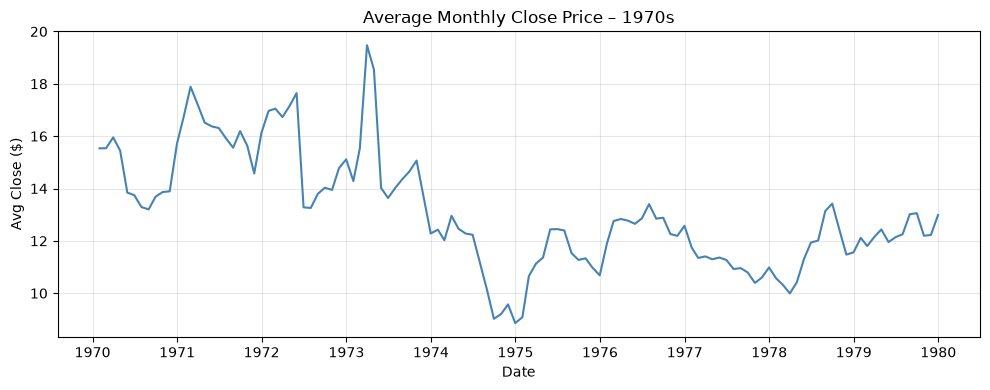

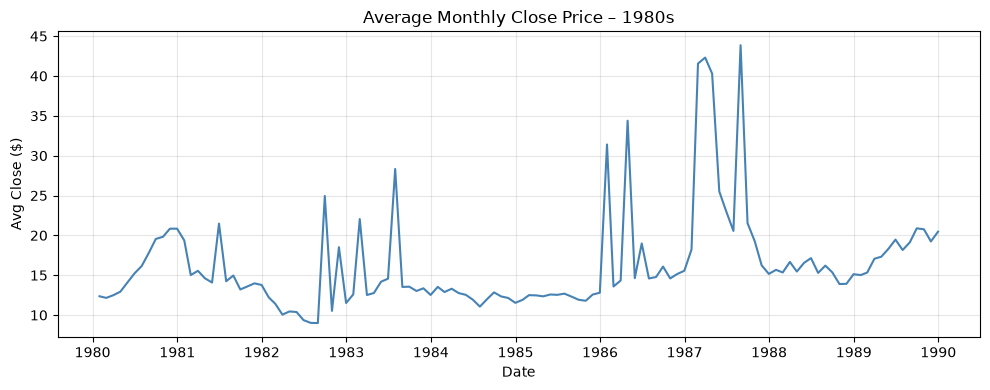

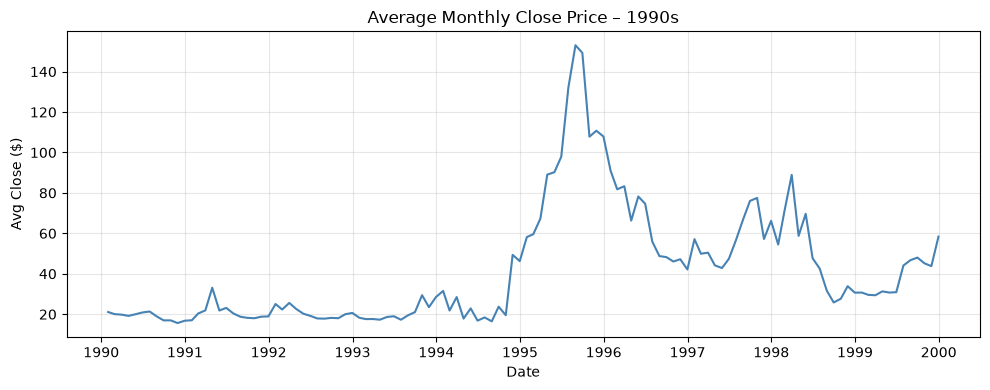

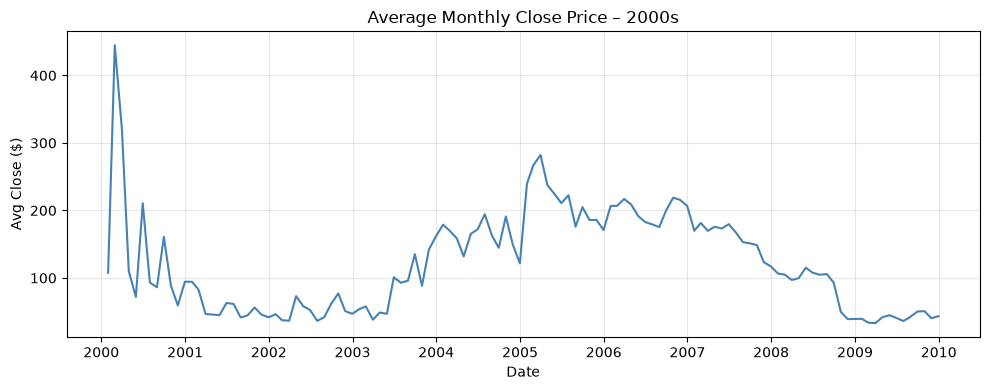

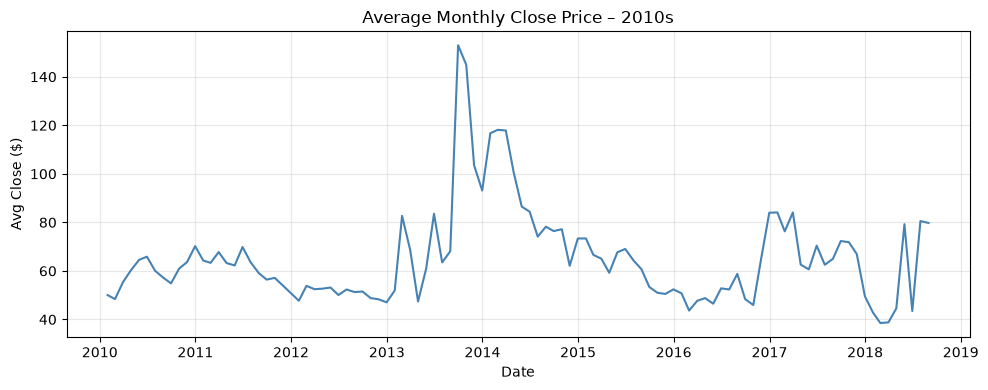

In [23]:
# 3. Time series plots for average monthly Close prices, one per decade
for d, df in sorted(decades.items()):
    monthly = df['close'].resample('ME').mean()

    plt.figure(figsize=(10, 4))
    plt.plot(monthly.index, monthly.values, color='steelblue', linewidth=1.5)
    plt.title(f'Average Monthly Close Price – {d}s')
    plt.xlabel('Date')
    plt.ylabel('Avg Close ($)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Analysis:
The charts show average monthly closing prices by decade: prices mostly stay low, with sudden spikes (about $43 in the 1980s, $150 in 1995, $440 in 2000) and a drop in 2008–09. Most spikes are likely caused by outliers pulling up the mean. Switch .mean() to .median() for a clearer trend.

In [65]:
#Definitions of clean prices
clean_prices = stock_prices[(stock_prices['adj_close'] > 0) &
                            (stock_prices['adj_close'] < 100_000)].copy()
clean_prices['decade'] = (clean_prices.index.year // 10) * 10
print(f'Removed {len(stock_prices) - len(clean_prices):,} rows')

Removed 4,060 rows


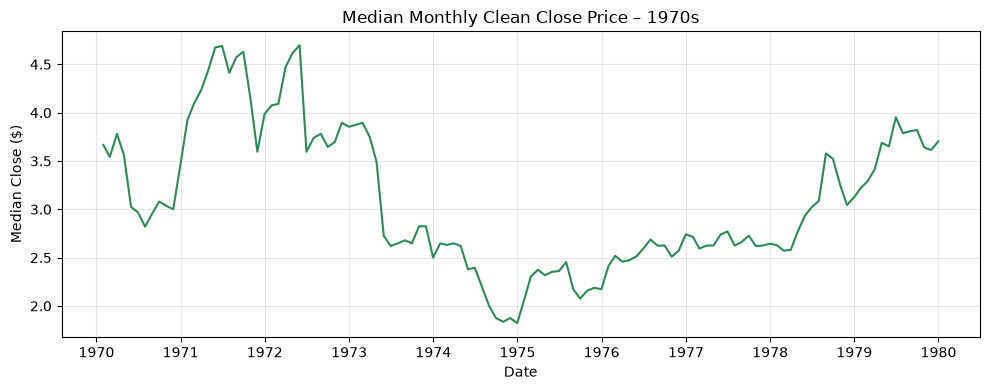

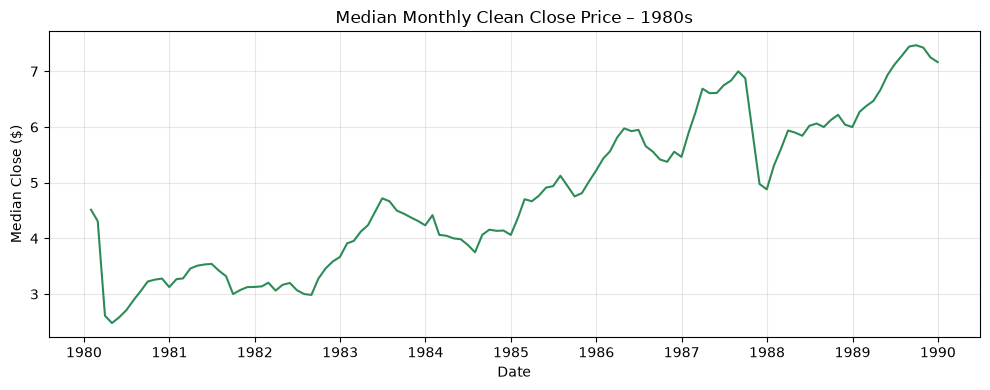

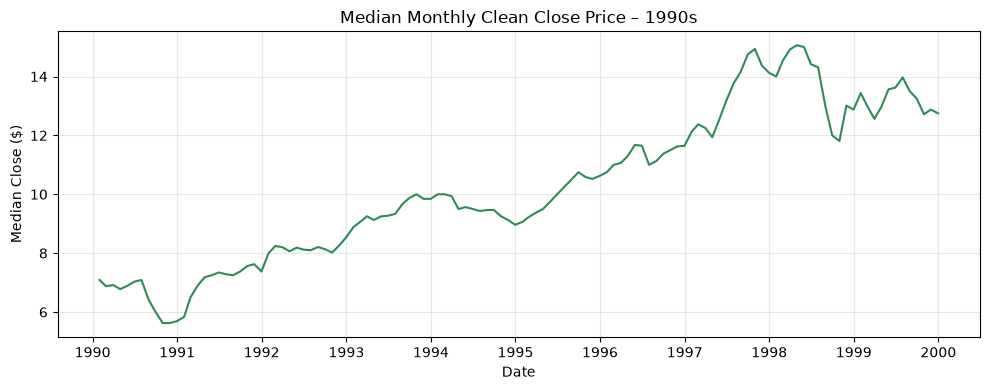

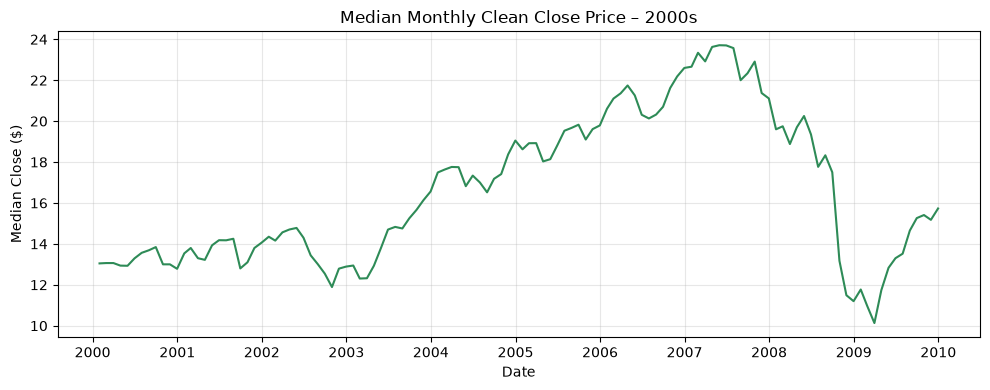

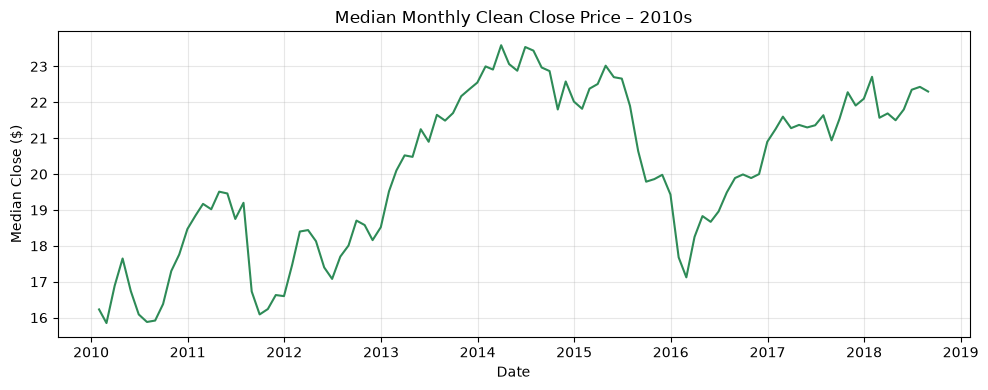

In [66]:
# Clean prices: rebuild decade segments from the CLEANED frame
decades_clean = {d: g for d, g in clean_prices.groupby('decade')}

for d, df in sorted(decades_clean.items()):
    monthly = df['close'].resample('ME').median()

    plt.figure(figsize=(10, 4))
    plt.plot(monthly.index, monthly.values, color='seagreen', linewidth=1.5)
    plt.title(f'Median Monthly Clean Close Price – {d}s')
    plt.xlabel('Date')
    plt.ylabel('Median Close ($)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Analysis:
The cleaned median prices trace real market history across all five decades.
1970s: the 1973–74 crash, then recovery.
1980s: steady growth, with a sharp dip at the 1987 crash.
1990s: a strong bull run from about $6 to $15, with a dip in 1998.
2000s: a rise to about $24 by 2007, then the 2008–09 financial crisis crash to about $10.
2010s: growth to about $23, a drop in 2015–16, then recovery.
Overall, typical stock prices rose from about $2 to $22 over 50 years, with each major crash clearly visible.

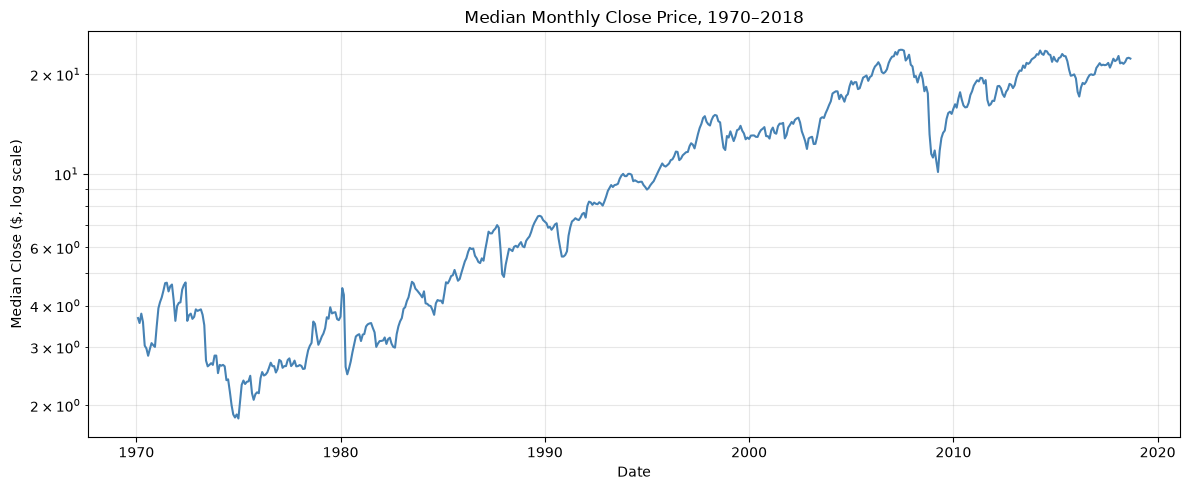

In [67]:
# Single continuous chart of median monthly close price
monthly_all = clean_prices['close'].resample('ME').median()

plt.figure(figsize=(12, 5))
plt.plot(monthly_all.index, monthly_all.values, color='steelblue', linewidth=1.5)
plt.yscale('log')
plt.title('Median Monthly Close Price, 1970–2018')
plt.xlabel('Date')
plt.ylabel('Median Close ($, log scale)')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Explanation:
From 1970 to 2018, the median stock price grew about 6x, from $3.70 to $22, at a steady rate. Major crashes (1974, 1987, 2002, 2009) show up as dips, and prices recovered after each one.

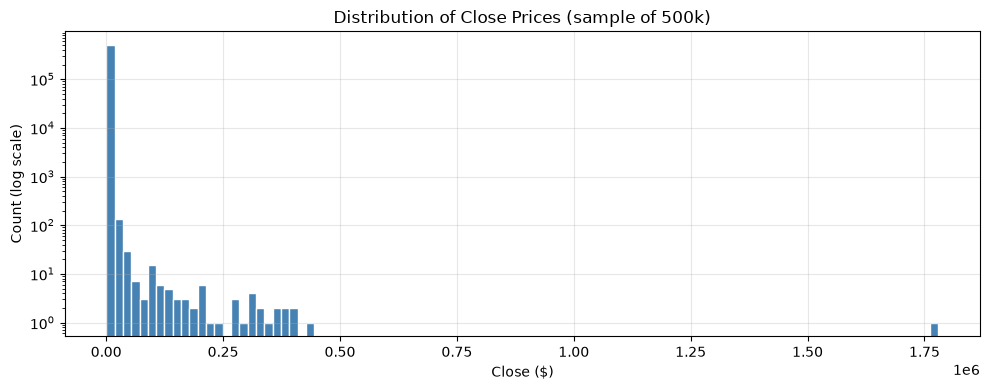

In [77]:
# Histograms and boxplots of close (on a sample for speed)
samp = stock_prices.sample(500_000, random_state=42)

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(samp['close'], bins=100, color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title('Distribution of Close Prices (sample of 500k)')
plt.xlabel('Close ($)')
plt.ylabel('Count (log scale)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explanation:
Almost all prices are near $0 on this scale, with a few rare extreme values up to about $1.78M. The data is extremely right-skewed. Use a log x-axis or filter outliers to see the real distribution.

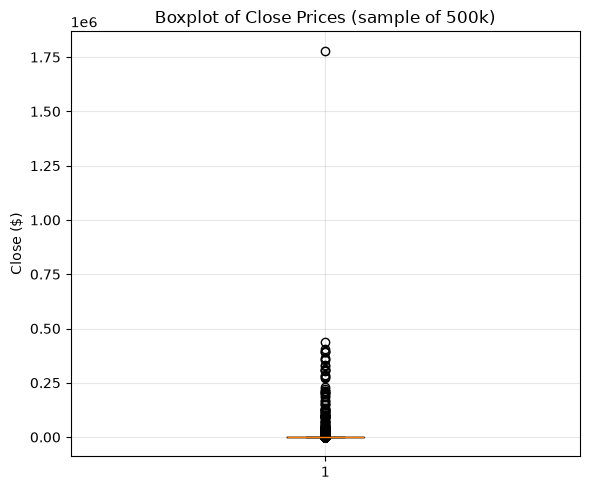

In [78]:
# Boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(samp['close'].dropna())
plt.title('Boxplot of Close Prices (sample of 500k)')
plt.ylabel('Close ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explanation:
The box itself is squashed flat near $0 because most prices are small (median about $15). The circles are outliers, with a cluster up to about $440K and one extreme value near $1.78M. It confirms the extreme right skew.

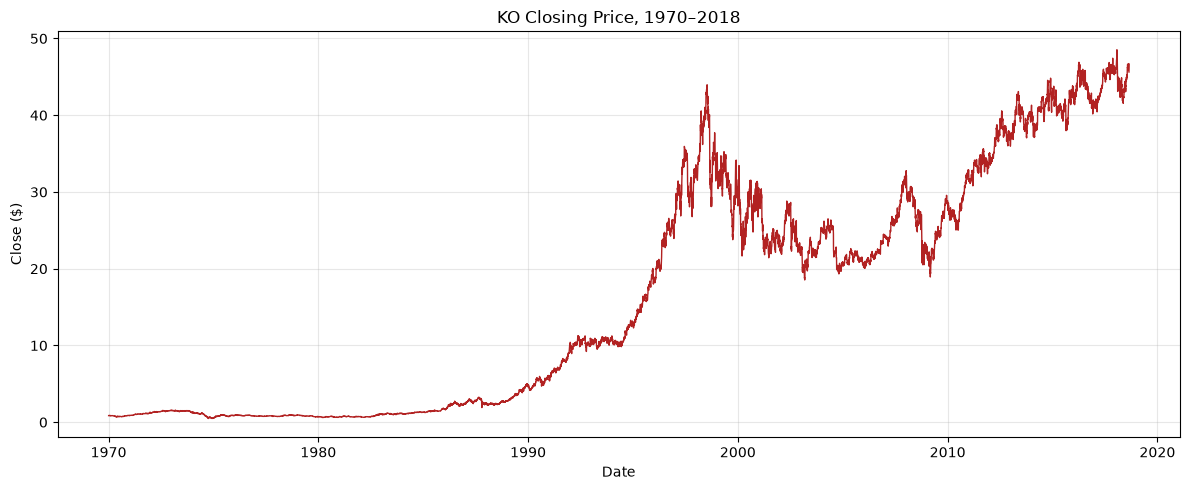

In [28]:
# One stock over time
one = stock_prices[stock_prices['ticker'] == 'KO'].sort_index()

plt.figure(figsize=(12, 5))
plt.plot(one.index, one['close'], color='firebrick', linewidth=1)
plt.title('KO Closing Price, 1970–2018')
plt.xlabel('Date')
plt.ylabel('Close ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explanation:
This chart shows Coca-Cola's (KO) closing price. It stayed flat at about $1 from 1970 to 1985, then grew strongly through the 1990s to a peak near $44 in 1998. It fell to about $20 by the early 2000s, dropped again in the 2008–09 crisis, then climbed steadily to about $47 by 2018. Overall, it's a classic long-term blue-chip growth story.

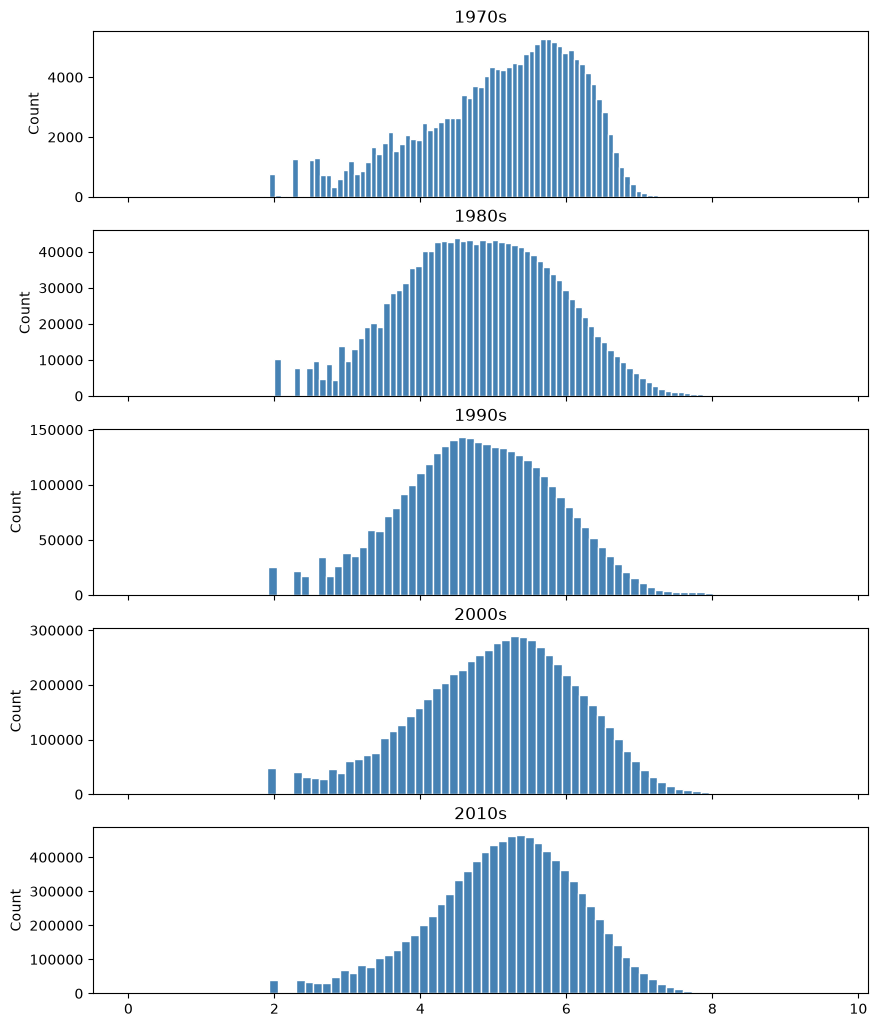

In [29]:
# Histograms for Volume by decade (log scale)
plot_df = stock_prices[stock_prices['volume'] > 0].copy()
plot_df['log_volume'] = np.log10(plot_df['volume'])

decade_list = sorted(plot_df['decade'].unique())

fig, axes = plt.subplots(len(decade_list), 1,
                         figsize=(10, 2.5 * len(decade_list)),
                         sharex=True)

for ax, d in zip(axes, decade_list):
    ax.hist(plot_df.loc[plot_df['decade'] == d, 'log_volume'],
            bins=80, color='steelblue', edgecolor='white')
    ax.set_title(f'{d}s')
    ax.set_ylabel('Count')

Explanation:
After a log transform, trading volume forms a bell curve in every decade, which means it's log-normal. Typical volume dipped in the 1980s–90s and rose again in the 2000s–2010s. The data also grows each decade as more stocks are added.

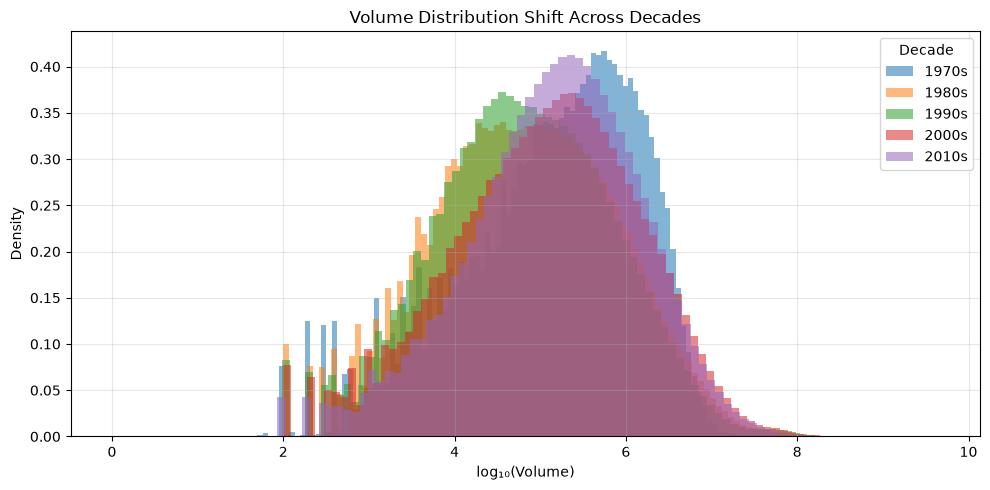

In [30]:
# Overlaid version: all decades on one chart
plt.figure(figsize=(10, 5))

for d in sorted(plot_df['decade'].unique()):
    plt.hist(plot_df.loc[plot_df['decade'] == d, 'log_volume'],
             bins=100, alpha=0.55, density=True, label=f'{d}s')

plt.title('Volume Distribution Shift Across Decades')
plt.xlabel('log₁₀(Volume)')
plt.ylabel('Density')
plt.legend(title='Decade')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explanation:
Volume stays log-normal in every decade, but the center shifts. It's highest in the 1970s (mostly big companies), lower in the 1980s–90s as small stocks were added, and higher again in the 2000s–2010s with electronic trading.

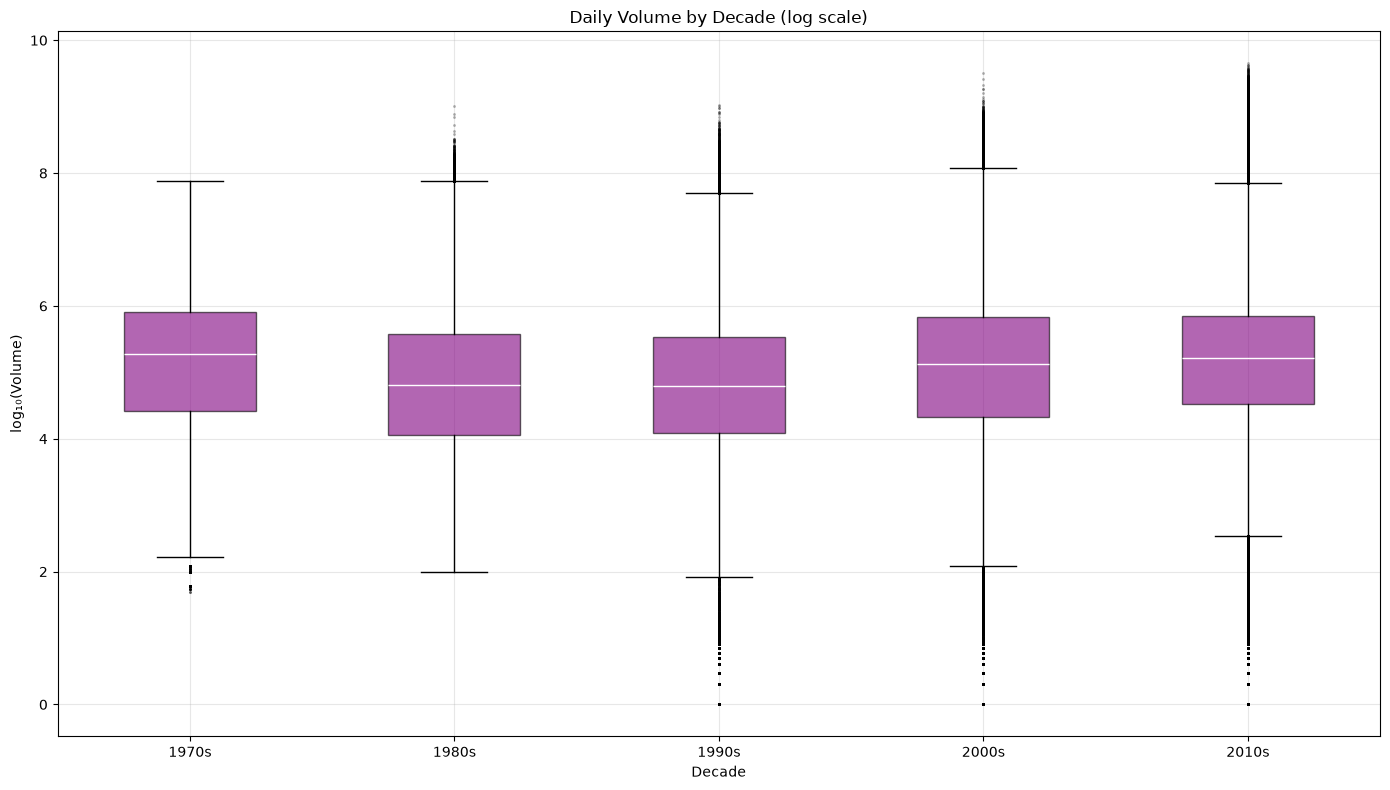

In [33]:
# Box plot of log volume by decade
decade_list = sorted(plot_df['decade'].unique())
data = [plot_df.loc[plot_df['decade'] == d, 'log_volume'] for d in decade_list]

plt.figure(figsize=(14, 8))
plt.boxplot(data, tick_labels=[f'{d}s' for d in decade_list], patch_artist=True, boxprops=dict(facecolor='purple', alpha=0.6),
            medianprops=dict(color='white'), flierprops=dict(marker='.', markersize=2, alpha=0.3))
plt.title('Daily Volume by Decade (log scale)')
plt.xlabel('Decade')
plt.ylabel('log₁₀(Volume)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Explanation:
Median volume (the white line) is highest in the 1970s (about 10^5.3), dips in the 1980s–90s (about 10^4.8), and rises again in the 2000s–2010s (about 10^5.2). The box sizes are similar, so the spread stays consistent. Outliers grow over time: by the 2010s, extreme days reach about 10^9.6, or roughly 4 billion shares, and very low-volume days (down to 1 share) appear from the 1990s onward.

Part 5: Comparative Analysis

In [34]:
#Compare the summary statistics across decades and document any notable trends or changes in stock price
#behaviors and trading volumes.
cols = ['open', 'high', 'low', 'adj_close', 'volume']

comparison = stock_prices.groupby('decade').agg(
    n_rows=('adj_close', 'size'),
    n_tickers=('ticker', 'nunique'),
    close_mean=('adj_close', 'mean'),
    close_median=('adj_close', 'median'),
    close_std=('adj_close', 'std'),
    vol_mean=('volume', 'mean'),
    vol_median=('volume', 'median'),
    vol_std=('volume', 'std')
).round(2)

comparison['close_cv'] = (comparison['close_std'] / comparison['close_mean']).round(2)
comparison['vol_skew_ratio'] = (comparison['vol_mean'] / comparison['vol_median']).round(2)

print(comparison)

         n_rows  n_tickers    close_mean  close_median     close_std  \
decade                                                                 
1970     164499         93  7.310000e+00          0.35  3.993000e+01   
1980    1470571        901  2.112523e+15          1.18  1.727534e+17   
1990    3427832       2117  1.476753e+09          4.87  7.314168e+11   
2000    6572053       3429  6.844700e+02         11.66  5.075891e+04   
2010    9338934       5685  6.246000e+01         17.79  1.841540e+03   

          vol_mean  vol_median      vol_std  close_cv  vol_skew_ratio  
decade                                                                 
1970     724893.64    187200.0   1377365.79      5.46            3.87  
1980     837523.35     64600.0   4510088.44     81.78           12.96  
1990     863527.19     62200.0   5834011.90    495.29           13.88  
2000    1383562.38    133400.0   9230142.84     74.16           10.37  
2010    1320505.22    165400.0  17707888.21     29.48          

In [35]:
print(stock_prices.nlargest(20, 'adj_close')[['ticker', 'adj_close', 'close', 'volume']])

           ticker     adj_close     close    volume
date                                               
1987-02-27    AAN  1.894962e+19  1.296296  346900.0
1987-03-10    AAN  1.894962e+19  1.296296   20200.0
1987-03-11    AAN  1.894962e+19  1.296296   18900.0
1987-03-12    AAN  1.894962e+19  1.296296   27000.0
1987-03-17    AAN  1.894962e+19  1.296296   31000.0
1987-03-18    AAN  1.894962e+19  1.296296  272700.0
1987-03-19    AAN  1.894962e+19  1.296296    4000.0
1987-03-25    AAN  1.894962e+19  1.296296  184900.0
1987-03-27    AAN  1.881428e+19  1.287037  205200.0
1987-03-26    AAN  1.854356e+19  1.268519   20200.0
1987-03-04    AAN  1.840821e+19  1.259259   24300.0
1987-03-09    AAN  1.840821e+19  1.259259   62100.0
1987-03-20    AAN  1.840821e+19  1.259259    9400.0
1987-03-23    AAN  1.840821e+19  1.259259    9400.0
1987-04-01    AAN  1.840821e+19  1.259259   18900.0
1987-03-02    AAN  1.813750e+19  1.240741  221400.0
1987-03-13    AAN  1.813750e+19  1.240741    1300.0
1987-03-16  

In [36]:
print((stock_prices['adj_close'] > 100_000).sum())
print((stock_prices['adj_close'] < 0).sum())
print(stock_prices['adj_close'].describe())

4059
0
count    2.097389e+07
mean     1.481184e+14
std      4.574674e+16
min      2.282650e-09
25%      4.620000e+00
50%      1.138199e+01
75%      2.472046e+01
max      1.894962e+19
Name: adj_close, dtype: float64


In [37]:
# Header-like ticker records
print(hist_stock[hist_stock['ticker'].str.contains('ticker', case=False, na=False)])
print(stock_prices[stock_prices['ticker'].str.len() > 6]['ticker'].unique()[:20])

Empty DataFrame
Columns: [ticker, exchange, name, sector, industry]
Index: []
<StringArray>
[]
Length: 0, dtype: str


In [38]:
# The sector bar chart shows a category called "SECTOR" , looks like a header row.
suspect = hist_stock[hist_stock['sector'].str.upper().eq('SECTOR') |
                     hist_stock['industry'].str.upper().eq('INDUSTRY')]
print(suspect)

    ticker exchange  name  sector  industry
74  Symbol     NYSE  NAME  SECTOR  INDUSTRY


In [39]:
# Only remove it if the row is clearly a header, not a real company:
hist_stock = hist_stock.drop(suspect.index).reset_index(drop=True)
print('Rows after removal:', len(hist_stock))
print('Sectors now:', hist_stock['sector'].nunique())

Rows after removal: 6459
Sectors now: 12


In [40]:
bad = stock_prices[stock_prices['adj_close'] > 10_000]
print(bad[['ticker', 'close', 'adj_close']].head(20))

           ticker          close     adj_close
date                                          
1981-06-08   YRCW   72187.500000  7.185812e+04
1982-09-21   YRCW   74531.250000  7.419118e+04
1982-09-23   YRCW   74062.500000  7.372456e+04
1982-11-02   YRCW   72656.250000  7.232475e+04
1983-02-11   YRCW   87187.500000  8.678966e+04
1983-07-11   YRCW  139687.500000  1.390501e+05
1986-01-29   YRCW  245625.000000  2.445058e+05
1986-04-21   YRCW  271875.000000  2.706362e+05
1987-01-20    AAN       1.055556  1.543041e+19
1987-01-21    AAN       1.055556  1.543041e+19
1987-01-22    AAN       1.055556  1.543041e+19
1987-01-23    AAN       1.055556  1.543041e+19
1987-01-26    AAN       1.055556  1.543041e+19
1987-01-27    AAN       1.074074  1.570112e+19
1987-01-28    AAN       1.074074  1.570112e+19
1987-01-29    AAN       1.092593  1.597182e+19
1987-01-30    AAN       1.092593  1.597182e+19
1987-02-02    AAN       1.074074  1.570112e+19
1987-02-03    AAN       1.074074  1.570112e+19
1987-02-04   

In [41]:
clean_prices = stock_prices[
    (stock_prices['adj_close'] > 0) &
    (stock_prices['adj_close'] < 100_000)
]
print(f"Removed {len(stock_prices) - len(clean_prices):,} rows")

Removed 4,060 rows


In [42]:
#Clear comparison, restrict tickeets present in all 5 decades.
per_decade = stock_prices.groupby('ticker')['decade'].nunique()
survivors = per_decade[per_decade == 5].index
print(len(survivors))

93


In [43]:
#New Summary from the cleaned frame
comparison = clean_prices.groupby('decade').agg(
    n_rows=('adj_close', 'size'),
    n_tickers=('ticker', 'nunique'),
    close_mean=('adj_close', 'mean'),
    close_median=('adj_close', 'median'),
    close_std=('adj_close', 'std'),
    vol_mean=('volume', 'mean'),
    vol_median=('volume', 'median'),
    vol_std=('volume', 'std')
).round(2)

comparison['close_cv'] = (comparison['close_std'] / comparison['close_mean']).round(2)
comparison['vol_skew_ratio'] = (comparison['vol_mean'] / comparison['vol_median']).round(2)

print(comparison)

         n_rows  n_tickers  close_mean  close_median  close_std    vol_mean  \
decade                                                                        
1970     164499         93        7.31          0.35      39.93   724893.64   
1980    1470110        900        9.22          1.18     183.06   837750.58   
1990    3427258       2117       30.29          4.87     779.01   863665.52   
2000    6569431       3429       58.05         11.65    1057.91  1384100.65   
2010    9338531       5685       52.54         17.79     699.74  1320560.15   

        vol_median      vol_std  close_cv  vol_skew_ratio  
decade                                                     
1970      187200.0   1377365.79      5.46            3.87  
1980       64700.0   4510773.57     19.85           12.95  
1990       62200.0   5834490.50     25.72           13.89  
2000      133500.0   9231939.47     18.22           10.37  
2010      165400.0  17708268.18     13.32            7.98  


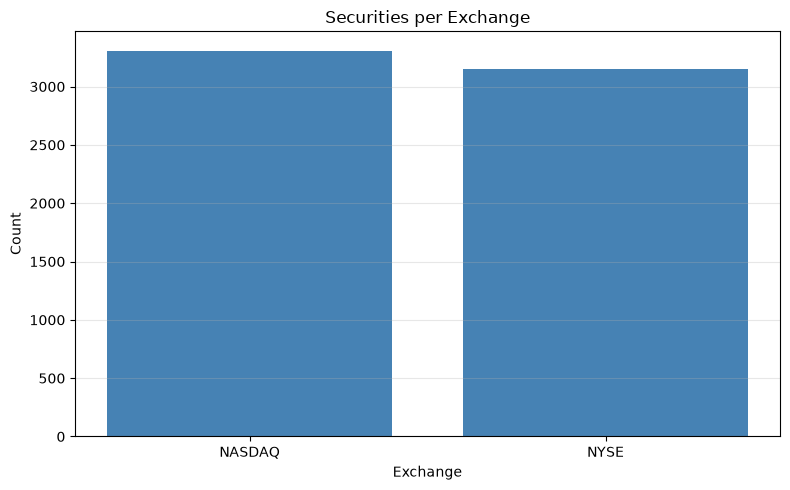

In [79]:
# Exchanges and sectors
exchange_counts = hist_stock['exchange'].value_counts()
sector_counts = hist_stock['sector'].value_counts()

# Securities per Exchange
plt.figure(figsize=(8, 5))
plt.bar(exchange_counts.index, exchange_counts.values, color='steelblue')
plt.title('Securities per Exchange')
plt.xlabel('Exchange')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

Explanation:
The dataset is fairly balanced between exchanges, with about 3,300 securities on NASDAQ and 3,150 on NYSE, or roughly 6,450 in total. NASDAQ has slightly more, so comparisons between the two exchanges won't be biased by sample size.

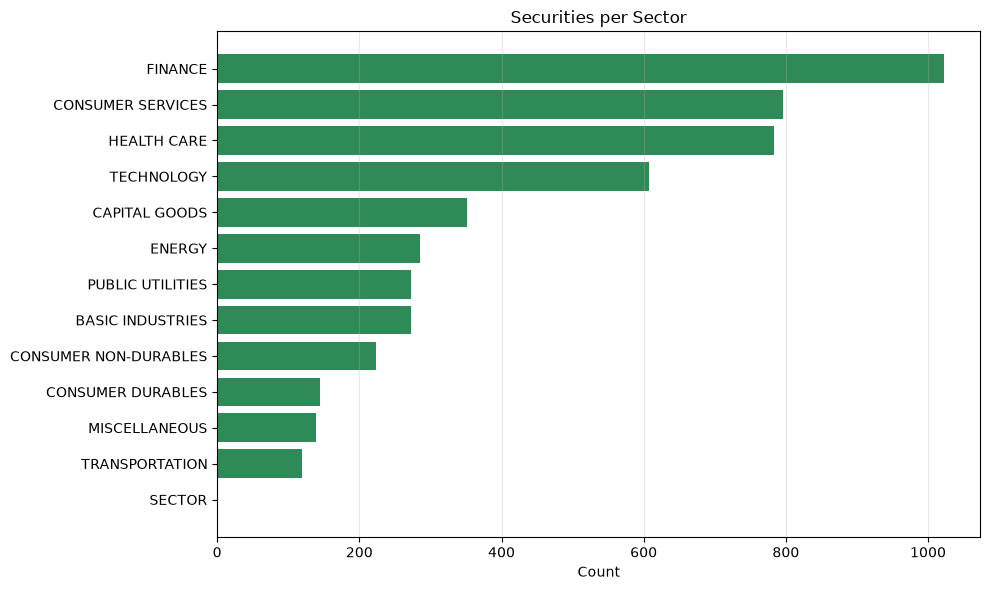

Missing sector: 1440


In [80]:
# Securities per Sector (horizontal so long names are readable)
plt.figure(figsize=(10, 6))
plt.barh(sector_counts.index, sector_counts.values, color='seagreen')
plt.gca().invert_yaxis()   # largest sector at the top
plt.title('Securities per Sector')
plt.xlabel('Count')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('Missing sector:', hist_stock['sector'].isna().sum())

Explanation:
Finance has the most securities (about 1,020), followed by Consumer Services, Health Care, and Technology. There are two issues to fix: a stray "SECTOR" category (a header row read as data) and 1,440 securities with no sector.

In [71]:
#Highest CLOSE (you only did adj_close)
print(stock_prices.nlargest(15, 'close').reset_index()[
    ['ticker','date','open','high','low','close','volume']])

   ticker       date         open         high         low      close  volume
0    SCON 2000-02-28  1395000.000  1797750.000  1368000.00  1779750.0   400.0
1    SCON 2000-02-29  2034000.000  2070000.000  1440000.00  1595250.0   400.0
2    SCON 2000-03-13   900000.000  1404000.000   861750.00  1363500.0   300.0
3    CODA 2001-02-05  1354500.000  1736700.000  1354500.00  1354500.0    34.0
4    TVIX 2013-02-26  1375000.000  1542500.000  1300000.00  1347500.0   100.0
5    SCON 2000-03-02  1120500.000  1368000.000  1098280.75  1261125.0   200.0
6    SCON 2000-02-25   873561.625  1369125.000   873000.00  1215000.0   200.0
7    TOPS 2016-08-01   783000.000  1276200.000   783000.00  1189800.0   100.0
8    SCON 2000-03-01  1368000.000  1512000.000  1107000.00  1134000.0   300.0
9    SCON 2000-03-14  1352250.000  1354500.000  1080000.00  1111500.0   100.0
10   TVIX 2013-03-19   997500.000  1110000.000   985000.00  1007500.0   100.0
11   SCON 2000-03-07   900000.000  1065936.625   859500.00   997

In [75]:
os.makedirs('results', exist_ok=True)

# Summary tables (small, safe for GitHub)
summary.to_csv('results/decade_summary_stats.csv')
comparison.to_csv('results/decade_comparison_clean.csv')
sector_counts.to_csv('results/securities_per_sector.csv')
exchange_counts.to_csv('results/securities_per_exchange.csv')

# Median monthly close (small time series)
monthly_all.to_csv('results/median_monthly_close.csv')

# 100k-row sample of the cleaned data
clean_prices.sample(100_000, random_state=42).to_csv('results/clean_prices_sample.csv')

print(os.listdir('results'))

['before_after_tuning.csv', 'buy_sell_signals.csv', 'class_distribution.csv', 'clean_prices_sample.csv', 'clip_limits.csv', 'cluster_centroids.csv', 'cluster_competition.csv', 'cluster_profile.csv', 'cluster_vs_digit_crosstab.csv', 'cv_summary.csv', 'decade_comparison_clean.csv', 'decade_summary_stats.csv', 'elbow_silhouette.csv', 'embeddings_2d_sample_5k.csv', 'embedding_effectiveness.csv', 'external_load_digits_predictions.csv', 'feature_importance.csv', 'fit_thresholds.csv', 'median_monthly_close.csv', 'mismatch_table.csv', 'mnist_vs_load_digits.csv', 'nearest_clusters.csv', 'noise_robustness.csv', 'per_cluster_fit.csv', 'per_digit_accuracy.csv', 'reduced_space_clustering.csv', 'rf_before_after_part7.csv', 'securities_per_exchange.csv', 'securities_per_sector.csv', 'signal_counts.csv', 'split_class_distribution.csv', 'test_confusion_matrix.csv', 'test_predictions.csv', 'test_results.csv', 'trading_signals_sample_200k.csv', 'train_cluster_assignments.csv', 'validation_results.csv', '